In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from SynOmics.metrics.narrow_utility.BayesianComparison import BayesianComparison 

In [2]:
cancers = ["ccRCC", "Melanoma", "NSCLC"]
algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']

Cancer_dict = {}

for cancer in cancers:
    pcs_df = pd.read_csv(f"../{cancer}/NarrowUtility/DGE/GCS/gcs_score.csv", index_col=0)

    tool_dict = {}
    for tool in algo:
        if tool not in pcs_df.columns:
            continue

        scores = pd.to_numeric(pcs_df[tool], errors="coerce").to_numpy(dtype=float)
        scores = scores[np.isfinite(scores)]  # drop NaN/inf

        if scores.size >= 2:
            tool_dict[tool] = scores.tolist()

    Cancer_dict[cancer] = tool_dict

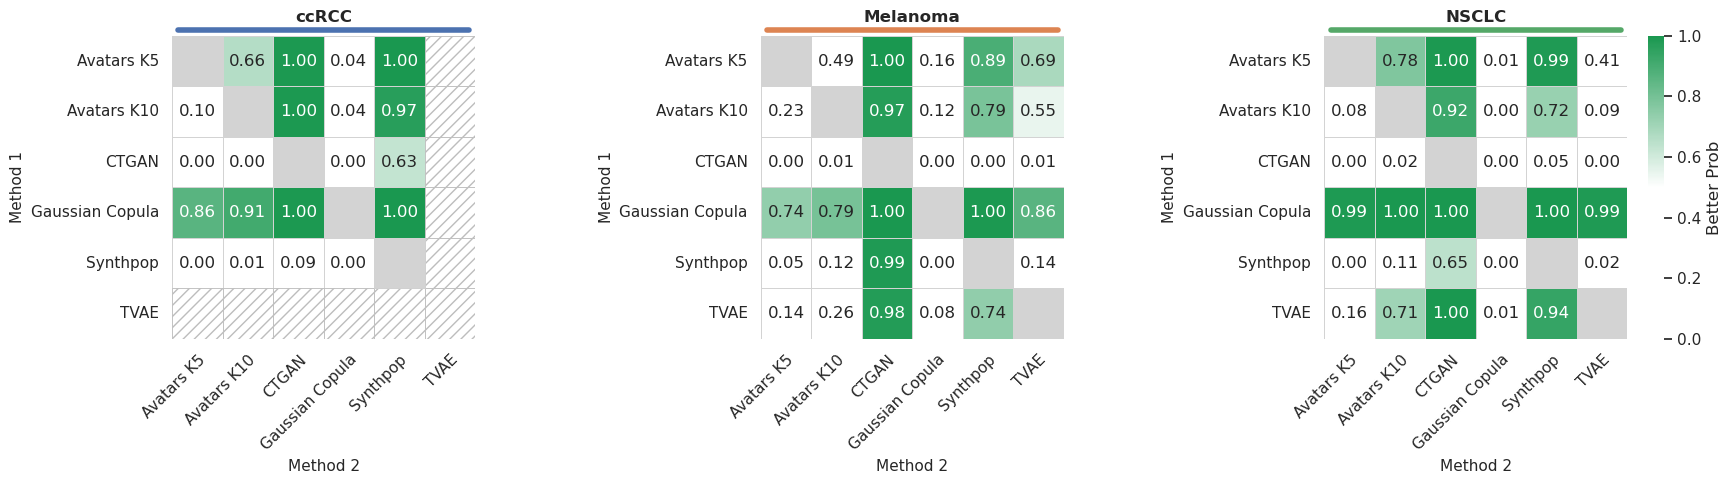

In [5]:
bc = BayesianComparison(rope=0.01)
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
fig, axes, mats_by_cancer, comps_by_cancer = bc.plot_pbetter_heatmap_grid(
    cancer_to_method_scores=Cancer_dict,
    cancers_order=("ccRCC", "Melanoma", "NSCLC"),
    methods_order=methods_order,
    value_col="Better Prob",
    figsize = (18,5),
    annot=True,
    fmt=".2f",
    show=True,
)

fig.savefig("bayesian_comp_fig4a_gcs.pdf", bbox_inches="tight", facecolor="white")
for cancer in cancers:
    bayesian_comp_df = comps_by_cancer[cancer]
    bayesian_comp_df.to_csv(f'GCS_Bayesian_{cancer}.csv')